# 03 Konstrukcja BWCI v0.1

Cel: zbudować pierwszą roboczą definicję **Behavioral Work Continuity Index (BWCI)** na podstawie decyzji z notebooka 02.

Ten notebook nie jest jeszcze modelem ML i nie tworzy finalnego zbioru treningowego. Jego zadaniem jest:

1. jawnie zastosować decyzje jakościowe z EDA,
2. zbudować rolling-window features,
3. zaproponować komponenty BWCI,
4. porównać wariant absolutny i percentylowy per-user,
5. zdefiniować robocze etykiety przyszłego pogorszenia ciągłości pracy,
6. sprawdzić wrażliwość na okno, wagi i normalizację.

## Założenia metodologiczne

- BWCI opisuje behawioralną ciągłość pracy, nie skupienie psychologiczne.
- Etykiety w tym notebooku są **wewnętrznym proxy**, nie ground truth.
- Definicja v0.1 ma być interpretowalna i odporna na problemy jakościowe wykryte w notebooku 02.
- Nie używamy `click_speed_average_*` w pierwszej wersji BWCI, bo `click_speed_average_0` ma ekstremalne wartości timestamp-like.
- `current_app_foreground_time` traktujemy jako cechę wymagającą cappingu/flagowania, nie jako samodzielny rdzeń indeksu.

In [ ]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data/BEHACOM/Behacom")
ENCODING = "latin-1"
EXCLUDE_USERS: list[int] = [2]
WINDOWS: list[int] = [10, 20, 30]
HORIZONS: list[int] = [5, 10, 15]

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Ładowanie danych i decyzje jakościowe

Ładujemy tylko kolumny potrzebne do konstrukcji BWCI v0.1. Celowo pomijamy:

- digrafy,
- per-key keystroke/timing columns,
- click speed columns.

Decyzje z notebooka 02 przeniesione tutaj:

- `User2` wykluczony z powodu bardzo małej liczby wierszy,
- `current_app_foreground_time > 60` oznaczamy flagą i przycinamy do 60 sekund,
- semantyczne zera zostają w danych, ale komponenty klawiaturowe liczymy warunkowo.

In [2]:
def discover_csv_files(data_dir: Path) -> list[Path]:
  """ Discover BEHACOM user CSV files sorted by numeric user id.

    Args:
      data_dir: BEHACOM directory containing User* subdirectories.

    Returns:
      list[Path]: CSV file paths sorted by numeric user id.
  """

  def sort_key(path: Path) -> int:
    """ Extract a numeric user id from a BEHACOM CSV path. """
    match = re.search(r"User(\d+)", path.parent.name)
    return int(match.group(1)) if match else 10_000

  return sorted(data_dir.glob("User*/User*_BEHACOM.csv"), key=sort_key)


def get_bwci_source_columns(sample_path: Path) -> list[str]:
  """ Select source columns used by the BWCI v0.1 notebook.

    Args:
      sample_path: One BEHACOM CSV used to inspect the header.

    Returns:
      list[str]: Column names to load.
  """
  header = pd.read_csv(sample_path, encoding=ENCODING, nrows=0).columns.tolist()
  skip_prefixes = (
    "digraph_",
    "keystrokes_key_",
    "press_release_average_",
    "click_speed_average_",
    "click_speed_stddev_",
  )
  keep: list[str] = []
  for col in header:
    if col == "press_release_average_interval":
      keep.append(col)
      continue
    if any(col.startswith(prefix) for prefix in skip_prefixes):
      continue
    keep.append(col)
  return keep


def load_behacom_core(data_dir: Path) -> pd.DataFrame:
  """ Load selected BEHACOM columns for BWCI construction.

    Args:
      data_dir: BEHACOM directory containing user CSV files.

    Returns:
      pd.DataFrame: Combined selected dataset with helper columns.
  """
  files = discover_csv_files(data_dir)
  if not files:
    raise FileNotFoundError(f"No BEHACOM CSV files found under {data_dir.resolve()}")

  columns = get_bwci_source_columns(files[0])
  frames: list[pd.DataFrame] = []
  for path in files:
    chunk = pd.read_csv(path, encoding=ENCODING, usecols=columns, low_memory=False)
    frames.append(chunk)

  out = pd.concat(frames, ignore_index=True)
  out["USER"] = out["USER"].astype(int)
  out = out[~out["USER"].isin(EXCLUDE_USERS)].copy()
  out["datetime"] = pd.to_datetime(out["timestamp"], unit="ms", errors="coerce")
  out = out.sort_values(["USER", "datetime"]).reset_index(drop=True)
  out["obs_idx"] = out.groupby("USER").cumcount()

  mouse_action_cols = [col for col in out.columns if col.startswith("mouse_action_counter_")]
  out["mouse_total"] = out[mouse_action_cols].sum(axis=1)
  out["is_idle"] = (out["keystroke_counter"] == 0) & (out["mouse_total"] == 0)
  out["foreground_time_was_capped"] = out["current_app_foreground_time"] > 60
  out["current_app_foreground_time"] = out["current_app_foreground_time"].clip(upper=60)
  return out


df = load_behacom_core(DATA_DIR)
print(f"Loaded: {len(df):,} rows, {df['USER'].nunique()} users, {len(df.columns)} columns")
print(f"Excluded users: {EXCLUDE_USERS}")
print(f"Foreground time capped rows: {df['foreground_time_was_capped'].sum():,}")

assert 2 not in df["USER"].unique()
assert df["datetime"].notna().all()


Loaded: 166,879 rows, 11 users, 82 columns
Excluded users: [2]
Foreground time capped rows: 55


### Interpretacja ładowania i czyszczenia

Notebook używa mniejszego, celowego zestawu kolumn niż poprzedni EDA. To jest świadoma decyzja: BWCI v0.1 ma być interpretowalny i odporny na największe problemy jakościowe.

Wyłączenie `click_speed_average_*` jest konserwatywne. Te kolumny można wrócić później po osobnej analizie, ale nie powinny wpływać na pierwszą definicję indeksu.

## Sekcja 2: Audyt ciągłości czasu

Rolling windows liczone po wierszach zakładają, że kolejne rekordy są kolejnymi 1-minutowymi oknami obserwacji. Przed użyciem rolling windows sprawdzamy, czy występują duże przerwy czasowe.

In [3]:
time_gap_rows: list[dict[str, object]] = []
for uid in sorted(df["USER"].unique()):
  udf = df[df["USER"] == uid].copy()
  deltas_min = udf["datetime"].diff().dt.total_seconds().div(60)
  time_gap_rows.append(
    {
      "user": uid,
      "rows": len(udf),
      "median_delta_min": deltas_min.median(),
      "p95_delta_min": deltas_min.quantile(0.95),
      "max_delta_min": deltas_min.max(),
      "gaps_gt_5min": int((deltas_min > 5).sum()),
      "gaps_gt_60min": int((deltas_min > 60).sum()),
    }
  )

time_gaps_df = pd.DataFrame(time_gap_rows)
time_gaps_df

,user,rows,median_delta_min,p95_delta_min,max_delta_min,gaps_gt_5min,gaps_gt_60min
0,0,6059,1.0382,1.1052,7048.4141,94,72
1,1,42281,1.3842,1.6033,291.7943,212,1
2,3,3221,1.0550,1.4515,15616.6470,62,36
3,4,10114,1.0612,1.1593,14294.1906,127,75
4,5,2128,1.0653,1.1335,690.1128,6,6
5,6,1332,1.0421,1.0777,10106.1014,12,10
6,7,55778,1.0411,1.1492,8476.3986,7,4
7,8,5404,1.0931,1.2314,19904.3583,50,28
8,9,7920,1.0514,1.1354,5447.6226,55,42
9,10,15358,1.0667,1.1371,4204.1182,91,80


### Interpretacja ciągłości czasu

Jeżeli występują duże przerwy, rolling window oznacza „ostatnie N obserwowanych minutowych rekordów”, a nie zawsze dokładnie ostatnie N minut zegarowych. To nie dyskwalifikuje analizy, ale ogranicza interpretację.

Dla BWCI v0.1 przyjmujemy rolling po obserwowanych wierszach jako wariant startowy. W późniejszym etapie można porównać go z resamplingiem do pełnej siatki minutowej.

## Sekcja 3: Rolling-window features

Budujemy cechy dla okien 10, 20 i 30 obserwowanych rekordów per użytkownik.

W tej wersji rolling features zawierają:

- proporcję idle,
- intensywność klawiatury i myszy,
- korekty klawiaturowe,
- przełączanie aplikacji,
- średni czas utrzymania bieżącej aplikacji na pierwszym planie,
- regularność rytmu pisania, jeśli w oknie jest wystarczająco dużo klawiszy.

Świadomie nie liczymy jeszcze entropii aplikacji w oknie. To potencjalnie dobra cecha, ale jej dokładne liczenie na surowych nazwach aplikacji jest kosztowne i wymaga osobnej, zoptymalizowanej decyzji implementacyjnej. Dla BWCI v0.1 stabilność kontekstu opisujemy prościej: mniej przełączeń aplikacji oraz dłuższe utrzymanie aplikacji foreground.


In [4]:
def build_rolling_features(source_df: pd.DataFrame, window: int) -> pd.DataFrame:
  """ Build rolling features for BWCI construction.

    Args:
      source_df: Cleaned 1-minute BEHACOM data sorted by user and time.
      window: Rolling window size in observed rows.

    Returns:
      pd.DataFrame: Rolling features with one row per source row after filtering fully idle windows.
  """
  results: list[pd.DataFrame] = []
  min_periods = max(1, window // 2)

  for uid in sorted(source_df["USER"].unique()):
    udf = source_df[source_df["USER"] == uid].reset_index(drop=True)

    rolled = pd.DataFrame(
      {
        "USER": uid,
        "obs_idx": udf["obs_idx"],
        "datetime": udf["datetime"],
        "keystroke_sum": udf["keystroke_counter"].rolling(window, min_periods=min_periods).sum(),
        "mouse_sum": udf["mouse_total"].rolling(window, min_periods=min_periods).sum(),
        "word_sum": udf["word_counter"].rolling(window, min_periods=min_periods).sum(),
        "erase_sum": udf["erase_keys_counter"].rolling(window, min_periods=min_periods).sum(),
        "switch_sum": udf["changes_between_apps"].rolling(window, min_periods=min_periods).sum(),
        "idle_ratio": udf["is_idle"].rolling(window, min_periods=min_periods).mean(),
        "press_press_mean": udf["press_press_average_interval"].rolling(window, min_periods=min_periods).mean(),
        "press_press_std": udf["press_press_stddev_interval"].rolling(window, min_periods=min_periods).mean(),
        "foreground_time_mean": udf["current_app_foreground_time"].rolling(window, min_periods=min_periods).mean(),
        "foreground_time_capped_sum": udf["foreground_time_was_capped"].rolling(window, min_periods=min_periods).sum(),
        "active_apps_mean": udf["active_apps_average"].rolling(window, min_periods=min_periods).mean(),
      }
    )
    rolled["window"] = window
    results.append(rolled)

  out = pd.concat(results, ignore_index=True)
  out = out[out["idle_ratio"] < 1.0].copy()
  out["input_sum"] = out["keystroke_sum"] + out["mouse_sum"]
  out["erase_ratio"] = np.where(out["keystroke_sum"] > 0, out["erase_sum"] / out["keystroke_sum"], np.nan)
  out["typing_cv"] = np.where(out["press_press_mean"] > 0, out["press_press_std"] / out["press_press_mean"], np.nan)
  out["foreground_focus_share"] = (out["foreground_time_mean"] / 60).clip(0, 1)
  return out


rolling_by_window: dict[int, pd.DataFrame] = {window: build_rolling_features(df, window) for window in WINDOWS}
rolling_summary = pd.DataFrame(
  [
    {
      "window": window,
      "rows": len(data),
      "users": data["USER"].nunique(),
      "median_idle_ratio": data["idle_ratio"].median(),
      "median_input_sum": data["input_sum"].median(),
      "median_switch_sum": data["switch_sum"].median(),
      "median_foreground_focus_share": data["foreground_focus_share"].median(),
    }
    for window, data in rolling_by_window.items()
  ]
)
rolling_summary


,window,rows,users,median_idle_ratio,median_input_sum,median_switch_sum,median_foreground_focus_share
0,10,76149,11,0.2000,6157.0000,1.0000,0.9439
1,20,84053,11,0.3000,11031.0000,2.0000,0.9500
2,30,88234,11,0.3667,15708.0000,4.0000,0.9435


### Interpretacja rolling features

Liczba rolling rows rośnie z długością okna, bo dłuższe okno częściej zawiera przynajmniej jedną aktywną minutę i nie jest odrzucane jako w pełni idle.

To ważne dla porównywania okien: okna 10/20/30 nie mają identycznych populacji obserwacji. Analiza wrażliwości musi więc wyrównywać rekordy po `USER` i `datetime`, a nie po pozycji indeksu.

W BWCI v0.1 stabilność kontekstu jest celowo prosta. Jeżeli późniejsze modele pokażą, że komponent kontekstu jest zbyt słaby lub zbyt mocno skorelowany z samą interakcją, wrócimy do bogatszych cech aplikacyjnych, np. entropii aplikacji liczonej zoptymalizowaną metodą.


## Sekcja 4: Komponenty BWCI v0.1

Definiujemy pięć komponentów. Każdy komponent ma interpretację „wyżej = większa ciągłość pracy”.

Dobór komponentów jest koncepcyjny i wynika z rodzin sygnałów dostępnych w BEHACOM, nie z dopasowania do etykiet ground-truth. BEHACOM nie ma prawdziwej etykiety „ciągłość pracy”, więc BWCI v0.1 jest operacjonalizacją proxy opartą na pięciu obserwowalnych aspektach pracy przy komputerze:

- aktywna obecność w oknie (`C_interaction_raw`),
- stabilność kontekstu aplikacji (`C_context_raw`),
- intensywność interakcji wejściowej (`C_input_raw`),
- regularność rytmu pisania (`C_regularity_raw`),
- niski udział korekt klawiaturowych (`C_correction_raw`).

| Komponent | Znaczenie | Decyzja |
|---|---|---|
| `C_interaction_raw` | aktywna część okna | `1 - idle_ratio` |
| `C_context_raw` | stabilność kontekstu aplikacji | mało przełączeń oraz dłuższe utrzymanie aplikacji foreground |
| `C_input_raw` | intensywność interakcji | robust percentile `input_sum` per user |
| `C_regularity_raw` | regularność rytmu pisania | `1 / (1 + typing_cv)`, tylko gdy jest pisanie |
| `C_correction_raw` | niska presja korekt | odwrotność znormalizowanego `erase_ratio`, tylko gdy jest pisanie |

To jest wersja v0.1: świadomie prosta, transparentna i możliwa do audytu. Nie zakładamy, że te komponenty są psychologicznymi wymiarami skupienia. Traktujemy je jako obserwowalne cechy zachowania, które razem tworzą proxy behawioralnej ciągłości pracy.

Komponenty klawiaturowe mogą mieć `NaN`, jeśli w oknie nie ma wystarczającej aktywności pisania. Przy kompozycie pomijamy brakujące komponenty, ale raportujemy ich pokrycie.

In [5]:
def robust_percentile_by_user(df: pd.DataFrame, col: str) -> pd.Series:
  """ Compute per-user percentile ranks for a column.

    Args:
      df: DataFrame containing USER and the target column.
      col: Column to rank.

    Returns:
      pd.Series: Percentile ranks in [0, 1].
  """
  return df.groupby("USER")[col].rank(pct=True)


def inverse_robust_scale_by_user(df: pd.DataFrame, col: str, q: float = 0.95) -> pd.Series:
  """ Convert an adverse metric into a per-user [0, 1] stability score.

    Args:
      df: DataFrame containing USER and the target column.
      col: Column where larger values are worse.
      q: Upper quantile used as robust cap.

    Returns:
      pd.Series: Score where larger values indicate better continuity.
  """
  result = pd.Series(index=df.index, dtype="float64")
  for _, idx in df.groupby("USER").groups.items():
    values = df.loc[idx, col]
    cap = values.quantile(q)
    cap = cap if pd.notna(cap) and cap > 0 else 1
    result.loc[idx] = 1.0 - (values / cap).clip(0, 1)
  return result


def compute_components(rolling_df: pd.DataFrame) -> pd.DataFrame:
  """ Compute raw and per-user normalized BWCI components.

    Args:
      rolling_df: Rolling feature DataFrame.

    Returns:
      pd.DataFrame: DataFrame with component columns.
  """
  out = rolling_df.copy()
  out["C_interaction_raw"] = (1.0 - out["idle_ratio"]).clip(0, 1)

  switch_stability = inverse_robust_scale_by_user(out, "switch_sum")
  foreground_stability = out["foreground_focus_share"].clip(0, 1)
  out["C_context_raw"] = pd.concat([switch_stability, foreground_stability], axis=1).mean(axis=1)

  out["C_input_raw"] = robust_percentile_by_user(out, "input_sum")

  enough_typing = out["keystroke_sum"] >= 5
  out["C_regularity_raw"] = np.nan
  out.loc[enough_typing & out["typing_cv"].notna(), "C_regularity_raw"] = (
    1.0 / (1.0 + out.loc[enough_typing & out["typing_cv"].notna(), "typing_cv"])
  ).clip(0, 1)

  out["C_correction_raw"] = np.nan
  correction_idx = enough_typing & out["erase_ratio"].notna()
  out.loc[correction_idx, "C_correction_raw"] = inverse_robust_scale_by_user(out.loc[correction_idx], "erase_ratio")

  raw_components = ["C_interaction_raw", "C_context_raw", "C_input_raw", "C_regularity_raw", "C_correction_raw"]
  for col in raw_components:
    norm_col = col.replace("_raw", "_pu")
    out[norm_col] = robust_percentile_by_user(out, col)

  return out


components_by_window: dict[int, pd.DataFrame] = {window: compute_components(data) for window, data in rolling_by_window.items()}
component_cols_raw = ["C_interaction_raw", "C_context_raw", "C_input_raw", "C_regularity_raw", "C_correction_raw"]
component_cols_pu = [col.replace("_raw", "_pu") for col in component_cols_raw]

coverage_rows: list[dict[str, object]] = []
for window, data in components_by_window.items():
  row: dict[str, object] = {"window": window, "rows": len(data)}
  for col in component_cols_raw:
    row[f"{col}_coverage_pct"] = round(data[col].notna().mean() * 100, 2)
  coverage_rows.append(row)

component_coverage_df = pd.DataFrame(coverage_rows)
component_coverage_df


,window,rows,C_interaction_raw_coverage_pct,C_context_raw_coverage_pct,C_input_raw_coverage_pct,C_regularity_raw_coverage_pct,C_correction_raw_coverage_pct
0,10,76149,100.0000,100.0000,100.0000,75.6100,75.6200
1,20,84053,100.0000,100.0000,100.0000,78.1300,78.2000
2,30,88234,100.0000,100.0000,100.0000,78.6100,78.6600


### Interpretacja komponentów

`C_interaction`, `C_context` i `C_input` mają pełne pokrycie, bo wynikają z aktywności lub struktury okna. `C_regularity` i `C_correction` są warunkowe: mają sens tylko, gdy w oknie wystąpiło pisanie.

To jest lepsze niż wymuszanie zer lub imputacji. Brak komponentu klawiaturowego oznacza „nieobserwowalne w tym oknie”, a nie automatycznie niską ciągłość pracy.

Warto też pamiętać, że `C_context` w tej wersji jest konserwatywny. Nie próbuje rozstrzygać, czy przełączenie aplikacji było korzystne czy szkodliwe; traktuje częste zmiany kontekstu jako wzrost ryzyka przerwania ciągłości behawioralnej.


## Sekcja 5: Kompozyt BWCI i warianty normalizacji

Liczymy dwa warianty:

- `BWCI_abs`: średnia z komponentów raw; zachowuje więcej skali absolutnej, ale jest bardziej zależna od profilu użytkownika.
- `BWCI_pu`: średnia z komponentów percentylowych per user; lepsza do wykrywania pogorszeń względem własnej normy użytkownika.

Wariant bazowy dla etykiet roboczych: `BWCI_pu`, bo celem jest pogorszenie ciągłości pracy względem typowego zachowania danej osoby.

In [6]:
def weighted_nanmean(df: pd.DataFrame, columns: list[str], weights: list[float] | None = None) -> pd.Series:
  """ Compute a weighted row-wise mean while ignoring NaN components.

    Args:
      df: DataFrame containing component columns.
      columns: Component columns to average.
      weights: Optional component weights.

    Returns:
      pd.Series: Weighted row-wise means.
  """
  values = df[columns].to_numpy(dtype="float64")
  if weights is None:
    weights_arr = np.ones(len(columns), dtype="float64")
  else:
    weights_arr = np.array(weights, dtype="float64")

  mask = ~np.isnan(values)
  weighted_sum = np.nansum(values * weights_arr[np.newaxis, :], axis=1)
  weight_sum = np.sum(mask * weights_arr[np.newaxis, :], axis=1)
  return pd.Series(np.where(weight_sum > 0, weighted_sum / weight_sum, np.nan), index=df.index)


bwci_by_window: dict[int, pd.DataFrame] = {}
for window, data in components_by_window.items():
  out = data.copy()
  out["BWCI_abs"] = weighted_nanmean(out, component_cols_raw)
  out["BWCI_pu"] = weighted_nanmean(out, component_cols_pu)
  out["observed_component_count"] = out[component_cols_raw].notna().sum(axis=1)
  bwci_by_window[window] = out

bwci_summary_rows: list[dict[str, object]] = []
for window, data in bwci_by_window.items():
  bwci_summary_rows.append(
    {
      "window": window,
      "rows": len(data),
      "BWCI_abs_mean": data["BWCI_abs"].mean(),
      "BWCI_abs_std": data["BWCI_abs"].std(),
      "BWCI_pu_mean": data["BWCI_pu"].mean(),
      "BWCI_pu_std": data["BWCI_pu"].std(),
      "median_observed_components": data["observed_component_count"].median(),
    }
  )

bwci_summary_df = pd.DataFrame(bwci_summary_rows)
bwci_summary_df

,window,rows,BWCI_abs_mean,BWCI_abs_std,BWCI_pu_mean,BWCI_pu_std,median_observed_components
0,10,76149,0.6031,0.1235,0.4932,0.1313,5.0000
1,20,84053,0.5802,0.1165,0.4948,0.1293,5.0000
2,30,88234,0.5672,0.1122,0.4957,0.1283,5.0000


### Interpretacja kompozytu

`BWCI_pu` nie powinien być używany do porównywania poziomu ciągłości między użytkownikami, bo normalizacja percentylowa usuwa część różnic bazowych. Jest natomiast sensowny jako roboczy indeks pogorszenia względem własnej normy.

`observed_component_count` trzeba zachować w dalszym modelowaniu jako kontrolę jakości: predykcje oparte na 3 komponentach nie są równoważne predykcjom opartym na 5 komponentach.

## Sekcja 6: Wizualizacje BWCI i korelacje komponentów

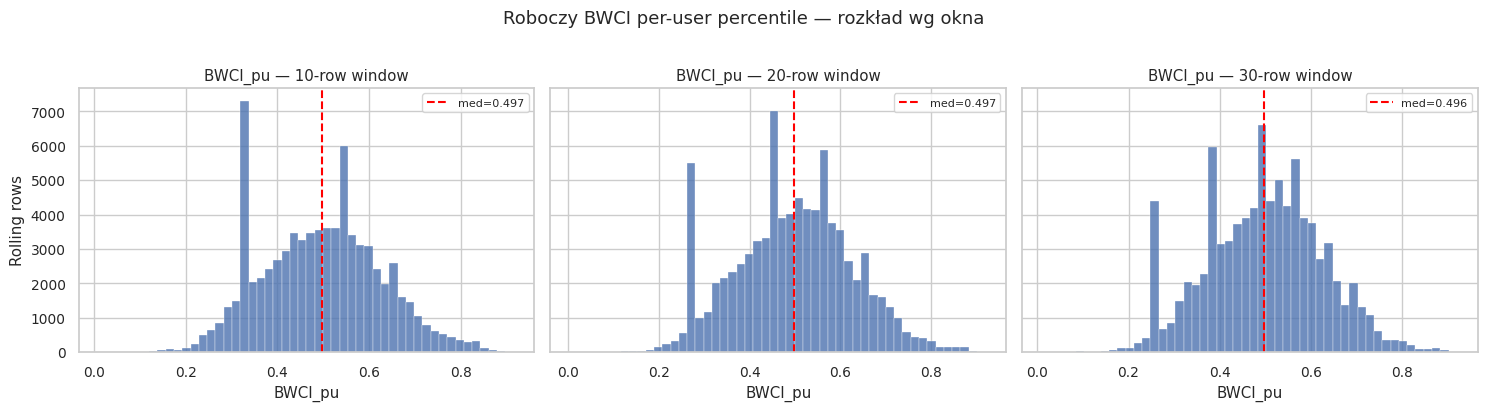

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, window in zip(axes, WINDOWS):
  data = bwci_by_window[window]
  ax.hist(data["BWCI_pu"].dropna(), bins=50, color="#4C72B0", alpha=0.8, edgecolor="white", linewidth=0.3)
  ax.axvline(data["BWCI_pu"].median(), color="red", linestyle="--", label=f"med={data['BWCI_pu'].median():.3f}")
  ax.set_title(f"BWCI_pu: {window}-row window")
  ax.set_xlabel("BWCI_pu")
  ax.legend(fontsize=8)
axes[0].set_ylabel("Rolling rows")
fig.suptitle("Roboczy BWCI per-user percentile, rozkład wg okna", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Interpretacja rozkładu BWCI_pu wg okna

Rozkłady dla okien 10, 20 i 30 są do siebie podobne i skoncentrowane wokół środka skali. Dla okna 10, które później przyjmujemy jako bazowe, `BWCI_pu` ma średnią `0.493`, medianę `0.497`, kwartyle około `0.390` i `0.582` oraz odchylenie standardowe `0.131`.

To wspiera użycie `BWCI_pu` jako roboczego indeksu: rozkład nie zapada się do stałej wartości i nie jest zdominowany przez skrajne obserwacje. Dłuższe okna nie zmieniają zasadniczo skali indeksu, więc wybór okna 10 jest bardziej decyzją o lokalności sygnału niż o ratowaniu problemu rozkładu.


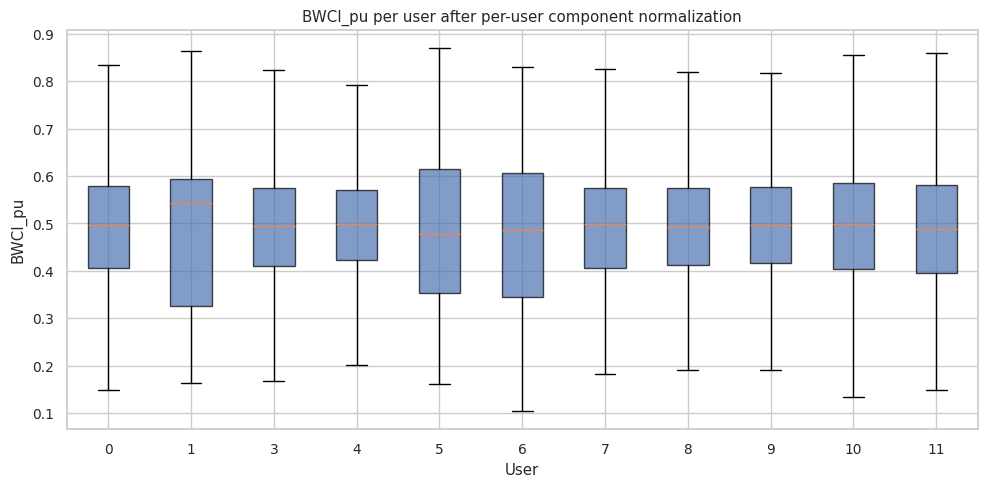

In [8]:
data10 = bwci_by_window[10]
fig, ax = plt.subplots(figsize=(10, 5))
users = sorted(data10["USER"].unique())
box_data = [data10.loc[data10["USER"] == uid, "BWCI_pu"].dropna().values for uid in users]
box = ax.boxplot(box_data, tick_labels=[str(uid) for uid in users], patch_artist=True, showfliers=False)
for patch in box["boxes"]:
  patch.set_facecolor("#4C72B0")
  patch.set_alpha(0.7)
ax.set_xlabel("User")
ax.set_ylabel("BWCI_pu")
ax.set_title("BWCI_pu per user after per-user component normalization")
fig.tight_layout()
plt.show()

### Interpretacja boxplotu per user

Po normalizacji per-user mediany większości użytkowników są blisko środka skali, zwykle około `0.49-0.50`. User 1 wyróżnia się wyższą medianą około `0.544` i większą masą powtarzalnych wartości; User 5 i User 6 mają relatywnie większą zmienność, ale mniej obserwacji.

Ten wykres nie służy do stwierdzenia, że jeden użytkownik ma „lepszą” ciągłość pracy od innego. Służy do kontroli, czy normalizacja nie tworzy wyraźnej patologii per user. Na tym etapie rozkład wygląda akceptowalnie dla konstrukcji indeksu, ale późniejszy audyt targetu pokazuje, że User 1 wymaga osobnej ostrożności przy etykietach progowych.


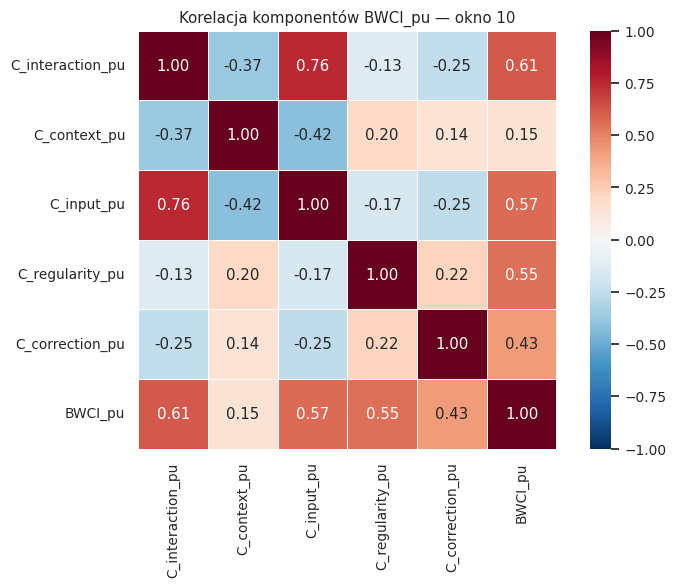

,component_a,component_b,corr
0,C_interaction_pu,C_input_pu,0.7563


In [9]:
corr = data10[component_cols_pu + ["BWCI_pu"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Korelacja komponentów BWCI_pu: okno 10")
fig.tight_layout()
plt.show()

strong_corr_rows: list[dict[str, object]] = []
for i, col_a in enumerate(component_cols_pu):
  for col_b in component_cols_pu[i + 1:]:
    corr_value = corr.loc[col_a, col_b]
    if abs(corr_value) >= 0.50:
      strong_corr_rows.append({"component_a": col_a, "component_b": col_b, "corr": corr_value})

pd.DataFrame(strong_corr_rows)

### Interpretacja korelacji komponentów

Macierz korelacji pokazuje jedną silną redundancję: `C_interaction_pu` i `C_input_pu` mają korelację około `0.756`. To oznacza, że aktywna część okna i intensywność wejścia częściowo mierzą ten sam ogólny sygnał aktywności.

Korelacje komponentów z kompozytem `BWCI_pu` są nierówne: `C_interaction_pu` około `0.609`, `C_input_pu` około `0.568`, `C_regularity_pu` około `0.547`, `C_correction_pu` około `0.425`, a `C_context_pu` tylko około `0.149`. W praktyce BWCI v0.1 jest więc mocniej napędzany aktywnością wejścia i rytmem pisania niż stabilnością kontekstu aplikacji.

To nie dyskwalifikuje v0.1, ale ogranicza interpretację: komponenty nie są niezależnymi wymiarami, a `C_context` ma słabszy udział niż zakładaliśmy koncepcyjnie. Dlatego późniejsze modelowanie musi mieć baseline autoregresyjny i analizę wrażliwości, zamiast traktować samą predykcję BWCI jako silną walidację indeksu.


### Wnioski z sekcji 6

Sekcja 6 wspiera dalsze użycie `BWCI_pu`, ale pokazuje też ograniczenia definicji v0.1. Indeks ma sensowną zmienność i nie wygląda na artefakt pojedynczego użytkownika, ale jego komponenty częściowo dublują sygnał aktywności.

Decyzja po tej sekcji: zostawiamy pięć komponentów w v0.1 ze względu na transparentność i porównywalność, ale nie przedstawiamy ich jako ostatecznej struktury latentnej. W dalszych etapach testujemy raczej użyteczność predykcyjną i wrażliwość targetu niż dowodzimy, że komponenty są psychologicznie niezależne.


## Sekcja 7: Robocze etykiety przyszłego pogorszenia

Definiujemy etykiety tylko jako **proxy do przyszłego modelowania**, nie jako prawdę o skupieniu.

Dwa warianty:

- `event_threshold_h`: przyszły `BWCI_pu` za h minut jest poniżej P25 użytkownika.
- `event_drop_h`: przyszły `BWCI_pu` spada o co najmniej 0.15 względem bieżącego okna.

Wariant threshold opisuje niski przyszły stan. Wariant drop opisuje spadek względem aktualnego stanu.

In [10]:
def add_future_proxy_labels(df: pd.DataFrame, horizons: list[int]) -> pd.DataFrame:
  """ Add future BWCI proxy labels per user.

    Args:
      df: DataFrame with USER, datetime, and BWCI_pu.
      horizons: Prediction horizons in observed rows.

    Returns:
      pd.DataFrame: DataFrame with future BWCI and event labels.
  """
  out = df.sort_values(["USER", "obs_idx"]).copy()
  user_q25 = out.groupby("USER")["BWCI_pu"].transform(lambda values: values.quantile(0.25))

  for horizon in horizons:
    future_col = f"BWCI_future_{horizon}"
    out[future_col] = out.groupby("USER")["BWCI_pu"].shift(-horizon)
    future = out[future_col]

    out[f"event_threshold_{horizon}"] = (future < user_q25).astype(float)
    out.loc[future.isna(), f"event_threshold_{horizon}"] = np.nan

    drop = future - out["BWCI_pu"]
    out[f"event_drop_{horizon}"] = (drop <= -0.15).astype(float)
    out.loc[future.isna(), f"event_drop_{horizon}"] = np.nan

  return out


labeled10 = add_future_proxy_labels(bwci_by_window[10], HORIZONS)

balance_rows: list[dict[str, object]] = []
for horizon in HORIZONS:
  for variant in ["threshold", "drop"]:
    col = f"event_{variant}_{horizon}"
    valid = labeled10[col].dropna()
    balance_rows.append(
      {
        "label": col,
        "valid_rows": len(valid),
        "positive_rows": int(valid.sum()),
        "positive_pct": round(valid.mean() * 100, 2),
      }
    )

label_balance_df = pd.DataFrame(balance_rows)
label_balance_df


,label,valid_rows,positive_rows,positive_pct
0,event_threshold_5,76094,15655,20.5700
1,event_drop_5,76094,6822,8.9700
2,event_threshold_10,76039,15637,20.5600
3,event_drop_10,76039,11962,15.7300
4,event_threshold_15,75984,15614,20.5500
5,event_drop_15,75984,12648,16.6500


### Interpretacja etykiet

`event_threshold` powinien dawać udział klas dodatnich zbliżony do dolnego kwartyla, ale nie dokładnie 25%, bo etykieta dotyczy przyszłej wartości i traci końcowe rekordy każdego użytkownika.

`event_drop` jest bardziej dynamiczny i może być rzadszy. Jeżeli będzie zbyt rzadki, modele klasyfikacyjne będą wymagały PR-AUC, precyzji/recallu i ostrożnej interpretacji class balance.

## Sekcja 8: Analiza wrażliwości

Sprawdzamy trzy rzeczy:

1. Czy równe wagi i alternatywne wagi dają podobny ranking.
2. Jak różni się wariant absolutny od percentylowego per-user.
3. Czy okna 10/20/30 są podobne po poprawnym wyrównaniu po `USER` + `datetime`.

In [11]:
alt_weights = [0.20, 0.25, 0.20, 0.20, 0.15]
base10 = bwci_by_window[10].copy()
base10["BWCI_pu_weighted"] = weighted_nanmean(base10, component_cols_pu, alt_weights)

sensitivity_rows: list[dict[str, object]] = []
sensitivity_rows.append(
  {
    "comparison": "equal_vs_weighted_10",
    "aligned_rows": len(base10),
    "correlation": base10["BWCI_pu"].corr(base10["BWCI_pu_weighted"]),
  }
)
sensitivity_rows.append(
  {
    "comparison": "abs_vs_per_user_10",
    "aligned_rows": len(base10),
    "correlation": base10["BWCI_abs"].corr(base10["BWCI_pu"]),
  }
)

for other_window in [20, 30]:
  left = bwci_by_window[10][["USER", "obs_idx", "datetime", "BWCI_pu"]].rename(columns={"BWCI_pu": "BWCI_10"})
  right = bwci_by_window[other_window][["USER", "obs_idx", "BWCI_pu"]].rename(columns={"BWCI_pu": f"BWCI_{other_window}"})
  aligned = left.merge(right, on=["USER", "obs_idx"], how="inner", validate="one_to_one")
  sensitivity_rows.append(
    {
      "comparison": f"window_10_vs_{other_window}",
      "aligned_rows": len(aligned),
      "correlation": aligned["BWCI_10"].corr(aligned[f"BWCI_{other_window}"]),
    }
  )

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


,comparison,aligned_rows,correlation
0,equal_vs_weighted_10,76149,0.9895
1,abs_vs_per_user_10,76149,0.8761
2,window_10_vs_20,76094,0.7404
3,window_10_vs_30,76041,0.6166


### Interpretacja wrażliwości

Porównanie okien musi być wyrównane po tej samej obserwacji użytkownika. Samo `USER + datetime` nie jest wystarczające, bo znaczniki czasu mogą się powtarzać lub nie tworzyć idealnie unikalnej siatki. Dlatego w notebooku używamy `obs_idx`, czyli kolejnego numeru obserwacji per użytkownik po sortowaniu czasowym, i wymuszamy merge `one_to_one`.

Jeżeli wariant wagowy jest bardzo silnie skorelowany z równymi wagami, równe wagi są bezpieczniejszym i prostszym wyborem dla v0.1. Jeżeli wariant absolutny i per-user różnią się istotnie, trzeba jasno wybrać, czy interesuje nas poziom bezwzględny czy pogorszenie względem własnej normy.


## Sekcja 9: Decyzje po konstrukcji BWCI v0.1

### Definicja robocza

Dla kolejnego etapu przyjmujemy roboczo:

- podstawowy indeks: `BWCI_pu`,
- podstawowe okno: 10 obserwowanych rekordów,
- podstawowa etykieta klasyfikacyjna do pierwszych modeli: `event_threshold_10`,
- alternatywna etykieta do analizy wrażliwości: `event_drop_10`.

### Ograniczenia

- BWCI jest proxy zbudowanym z tych samych rodzin cech, które później mogą być używane przez modele. Trzeba pilnować cyrkularności.
- Pierwsze modele powinny przewidywać przyszły BWCI/zdarzenie, nie bieżący indeks.
- `BWCI_pu` jest miarą względem profilu użytkownika, więc nie służy do oceniania, który użytkownik ma „lepszą” ciągłość pracy.
- Rolling po wierszach oznacza rolling po obserwowanych minutowych rekordach, nie zawsze po idealnej siatce zegarowej.
- Entropia aplikacji nie wchodzi do BWCI v0.1. Możemy ją dodać później, jeśli będzie potrzebna metodologicznie i technicznie.
- Notebook nie zapisuje jeszcze stabilnego datasetu do `outputs/`, bo definicja indeksu wymaga najpierw wspólnej akceptacji.

### Decyzje dla notebooka modelowego

1. Zbudować dataset predykcyjny z cech dostępnych do czasu `t` i etykietą z czasu `t+h`.
2. Dodać baseline autoregresyjny: przyszły BWCI przewidywany z bieżącego BWCI.
3. Raportować metryki regresji i klasyfikacji osobno.
4. Użyć walidacji czasowej i leave-one-user-out.
5. Zachować `observed_component_count` jako cechę kontrolną albo filtr jakości.
